# QMSSGR5074 - Project 3


### Your Group ID: 8
### Your UNIs: zs2770, xs2591
### Your Full Names: Zeyu Song, Xiangxinrui Shan
### Public GitHub Repo: https://github.com/Rachel-xs/Advanced_Machine_Learning_Project_3


## Description

## Part 1 – Data Ingestion & Preprocessing

1. **Data Loading**  
   - Acquire the Stanford Sentiment Treebank dataset.  
   - Split into training, validation and test sets with stratified sampling to preserve class balance.  
   - Clearly document your splitting strategy and resulting dataset sizes.

2. **Text Cleaning & Tokenization**  
   - Implement a reusable preprocessing pipeline that handles at least:  
     - HTML removal, lowercasing, punctuation stripping  
     - Vocabulary pruning (e.g., rare words threshold)  
     - Tokenization (character- or word-level)  
   - Expose this as a function/class so it can be saved and re-loaded for inference.

3. **Feature Extraction**  
   - **Traditional**: Build a TF-IDF vectorizer (or n-gram count) pipeline.  
   - **Neural**: Prepare sequences for embedding—pad/truncate to a fixed length.  
   - Save each preprocessor (vectorizer/tokenizer) to disk.

---

## Part 2 – Exploratory Data Analysis (EDA)

1. **Class Distribution**  
   - Visualize the number of positive vs. negative reviews.  
   - Compute descriptive statistics on review lengths (mean, median, IQR).  

2. **Text Characteristics**  
   - Plot the 20 most frequent tokens per sentiment class.  
   - Generate word clouds (or bar charts) highlighting key terms for each class.  

3. **Correlation Analysis**  
   - Analyze whether review length correlates with sentiment.  
   - Present findings numerically and with at least one visualization.

---

## Part 3 – Baseline Traditional Models

1. **Logistic Regression & SVM**  
   - Train at least two linear models on your TF-IDF features (e.g., logistic regression, linear SVM).  
   - Use cross-validation (≥ 5 folds) on the training set to tune at least one hyperparameter.  

2. **Random Forest & Gradient Boosting**  
   - Train two tree-based models (e.g., Random Forest, XGBoost) on the same features.  
   - Report feature-importance for each and discuss any notable tokens.

3. **Evaluation Metrics**  
   - Compute accuracy, precision, recall, F1-score, and ROC-AUC on the **held-out test set**.  
   - Present all results in a single comparison table.

---

## Part 4 – Neural Network Models

1. **Simple Feed-Forward**  
   - Build an embedding layer + a dense MLP classifier.  
   - Ensure you freeze vs. unfreeze embeddings in separate runs.

2. **Convolutional Text Classifier**  
   - Implement a 1D-CNN architecture (Conv + Pooling) for sequence data.  
   - Justify your choice of kernel sizes and number of filters.

3. **Recurrent Model (Optional)**  
   - (Stretch) Add an RNN or Bi-LSTM layer and compare performance/time vs. CNN.

---

## Part 5 – Transfer Learning & Advanced Architectures

1. **Pre-trained Embeddings**  
   - Retrain one network using pre-trained GloVe (or FastText) embeddings.  
   - Compare results against your from-scratch embedding runs.

2. **Transformer Fine-Tuning**  
   - Fine-tune a BERT-family model on the training data.  
   - Clearly outline your training hyperparameters (learning rate, batch size, epochs).


---

## Part 6 – Hyperparameter Optimization

1. **Search Strategy**  
   - Use a library (e.g., Keras Tuner, Optuna) to optimize at least two hyperparameters of one deep model.  
   - Describe your search space and stopping criteria.

2. **Results Analysis**  
   - Report the best hyperparameter configuration found.  
   - Plot validation-loss (or metric) vs. trials to illustrate tuning behavior.

---

## Part 7 – Final Comparison & Error Analysis

1. **Consolidated Results**  
   - Tabulate test-set performance for **all** models (traditional, neural, transfer-learned).  
   - Highlight top‐performing model overall and top in each category.

2. **Statistical Significance**  
   - Perform a significance test (e.g., McNemar’s test) between your best two models.  

3. **Error Analysis**  
   - Identify at least 20 examples your best model misclassified.  
   - For a sample of 5, provide the raw text, predicted vs. true label, and a short discussion of each error—what linguistic artifact might have confused the model?

---

## Part 8 – Optional Challenge Extensions

- Implement data augmentation for text (back-translation, synonym swapping) and measure its impact.  
- Integrate a sentiment lexicon feature (e.g., VADER scores) into your models and assess whether it improves predictions.  
- Deploy your best model as a simple REST API using Flask or FastAPI and demo it on a handful of user‐submitted reviews.

---

## Part 1 – Data Ingestion & Preprocessing


1. **Data Loading**  
    - Acquire the Stanford Sentiment Treebank dataset.
    - Split into training, validation, and test sets with stratified sampling to preserve class balance.
    - Clearly document your splitting strategy and resulting dataset sizes.
    

In [ ]:
import pandas as pd
import os
import numpy as np
from sklearn.model_selection import train_test_split

# IMPORT DATA
!git clone https://github.com/YJiangcm/SST-2-sentiment-analysis.git


DATA_PATH = "SST-2-sentiment-analysis/data"

train_raw = pd.read_csv(
    os.path.join(DATA_PATH, "train.tsv"),
    sep="\t",
    header=None,
    names=["sentiment", "review"])

dev_raw = pd.read_csv(
    os.path.join(DATA_PATH, "dev.tsv"),
    sep="\t",
    header=None,
    names=["sentiment", "review"])

test_raw = pd.read_csv(
    os.path.join(DATA_PATH, "test.tsv"),
    sep="\t",
    header=None,
    names=["sentiment", "review"])

df = pd.concat([train_raw, dev_raw, test_raw], ignore_index=True)

df= df.dropna(subset=["review", "sentiment"]).copy()
df["sentiment"] = df["sentiment"].astype(int)
df["review"]= df["review"].astype(str)

#80/10/10, 80% train, 10% validation, 10% test
train_df, temp_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["sentiment"])

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42,
    stratify=temp_df["sentiment"]
)





print("Full dataset size", df.shape)
print("Train size:", train_df.shape)
print("Validation size:", val_df.shape)
print("Test size:", test_df.shape)

print("\nClass balance in full data:")
print(df["sentiment"].value_counts(normalize=True).sort_index())

print("\nClass balance in train:")
print(train_df["sentiment"].value_counts(normalize=True).sort_index())

df.head()



fatal: destination path 'SST-2-sentiment-analysis' already exists and is not an empty directory.
Full dataset size (9613, 2)
Train size: (7690, 2)
Validation size: (961, 2)
Test size: (962, 2)

Class balance in full data:
sentiment
0    0.48372
1    0.51628
Name: proportion, dtype: float64

Class balance in train:
sentiment
0    0.483745
1    0.516255
Name: proportion, dtype: float64


,sentiment,review
0,1,"a stirring , funny and finally transporting re..."
1,0,apparently reassembled from the cutting-room f...
2,0,they presume their audience wo n't sit still f...
3,1,this is a visually stunning rumination on love...
4,1,jonathan parker 's bartleby should have been t...



2. **Text Cleaning & Tokenization**  
    - Implement a reusable preprocessing pipeline that handles at least:  
        - HTML removal, lowercasing, punctuation stripping  
        - Vocabulary pruning (e.g., rare words threshold)  
        - Tokenization (character- or word-level)  
    - Expose this as a function/class so it can be saved and re-loaded for inference.
    

In [ ]:

import re
import string
import joblib
from sklearn.feature_extraction.text import CountVectorizer

def clean_text(text):
    text = re.sub(r'<[^>]*>', '', text)  # Remove HTML tags
    text = text.lower()
    text = str(text)
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

for split_df in [train_df, val_df, test_df,df]:
    split_df['cleaned_review'] = split_df["review"].apply(clean_text)
    split_df["review_length"] = split_df["cleaned_review"].apply(lambda x: len(x.split()))

#vocabulary pruning
vocab_vectorizer = CountVectorizer(min_df=5, stop_words="english")
vocab_vectorizer.fit(train_df["cleaned_review"])

print("Vocabulary size after pruning:", len(vocab_vectorizer.vocabulary_))
print("Example cleaned text:")
print(train_df[["review", "cleaned_review", "sentiment"]].head())

#save the cleaning and vovab object for later use
joblib.dump(vocab_vectorizer, "count_vectorizer_vocab_pruned.joblib")

Vocabulary size after pruning: 2983
Example cleaned text:
                                                 review  \
668   there 's ... an underlying old world sexism to...   
3221  the film proves unrelentingly grim -- and equa...   
7935  it smacks of purely commercial motivation , wi...   
4552  a retread of material already thoroughly plumb...   
912   remarkable for its excellent storytelling , it...   

                                         cleaned_review  sentiment  
668   there s an underlying old world sexism to mond...          0  
3221  the film proves unrelentingly grim and equally...          1  
7935  it smacks of purely commercial motivation with...          0  
4552  a retread of material already thoroughly plumb...          0  
912   remarkable for its excellent storytelling its ...          1  


['count_vectorizer_vocab_pruned.joblib']


3. **Feature Extraction**  
    - **Traditional**: Build a TF-IDF vectorizer (or n-gram count) pipeline.  
    - **Neural**: Prepare sequences for embedding—pad/truncate to a fixed length.  
    - Save each preprocessor (vectorizer/tokenizer) to disk.
    

In [ ]:

from sklearn.feature_extraction.text import TfidfVectorizer
import joblib

# Initialize TF-IDF Vectorizer
vectorizer = TfidfVectorizer(
    max_features=5000,
    min_df=2,
    ngram_range=(1, 2),
    stop_words="english")


# Fit on cleaned text
X_train_tfidf = vectorizer.fit_transform(train_df["cleaned_review"])
X_val_tfidf = vectorizer.transform(val_df["cleaned_review"])
X_test_tfidf = vectorizer.transform(test_df["cleaned_review"])

y_train = train_df["sentiment"]
y_val = val_df["sentiment"]
y_test = test_df["sentiment"]

print("TF-IDF train shape:", X_train_tfidf.shape)
print("TF-IDF validation shape:", X_val_tfidf.shape)
print("TF-IDF test shape:", X_test_tfidf.shape)

#Save TF-IDF vectorizer
joblib.dump(vectorizer, "tfidf_vectorizer.joblib")
#neural feature extraction
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_WORDS = 10000
MAX_LEN = 50

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<00V>")
tokenizer.fit_on_texts(train_df["cleaned_review"])

X_train_seq = pad_sequences(
    tokenizer.texts_to_sequences(train_df["cleaned_review"]),
    maxlen=MAX_LEN,
    padding="post",
    truncating="post")

X_val_seq = pad_sequences(
    tokenizer.texts_to_sequences(val_df["cleaned_review"]),
    maxlen=MAX_LEN,
    padding="post",
    truncating="post")

X_test_seq = pad_sequences(
    tokenizer.texts_to_sequences(test_df["cleaned_review"]),
    maxlen=MAX_LEN,
    padding="post",
    truncating="post")

print("Nerual train shape:", X_train_seq.shape)
print("Nerual validation shape:", X_val_seq.shape)
print("Nerual test shape:", X_test_seq.shape)

#Save tokenizer
joblib.dump(tokenizer, "keras_tokenizer.joblib")



TF-IDF train shape: (7690, 5000)
TF-IDF validation shape: (961, 5000)
TF-IDF test shape: (962, 5000)
Nerual train shape: (7690, 50)
Nerual validation shape: (961, 50)
Nerual test shape: (962, 50)


['keras_tokenizer.joblib']

## Part 2 – Exploratory Data Analysis (EDA)


1. **Class Distribution**  
    - Visualize the number of positive vs. negative reviews.  
    - Compute descriptive statistics on review lengths (mean, median, IQR).
    
2. **Text Characteristics**  
   - Plot the 20 most frequent tokens per sentiment class.  
   - Generate word clouds (or bar charts) highlighting key terms for each class.  

3. **Correlation Analysis**  
   - Analyze whether review length correlates with sentiment.  
   - Present findings numerically and with at least one visualization.

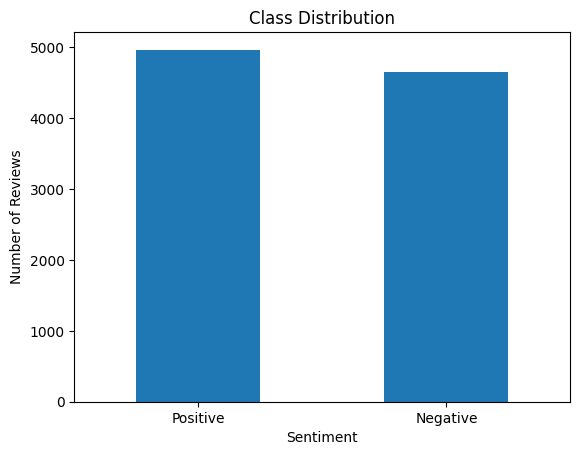

Class counts:
sentiment
Positive    4963
Negative    4650
Name: count, dtype: int64

Review length statistics:
count    9613.000000
mean       17.603038
std         8.731828
min         1.000000
25%        11.000000
50%        17.000000
75%        24.000000
max        52.000000
Name: review_length, dtype: float64
IQR: 13.0


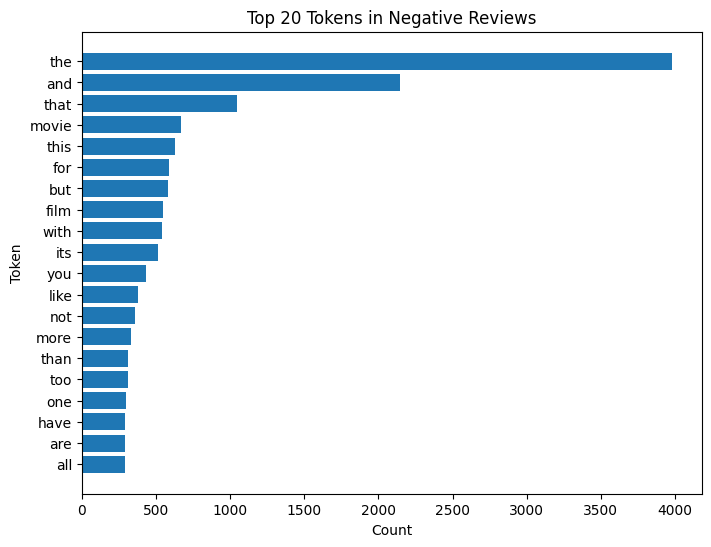

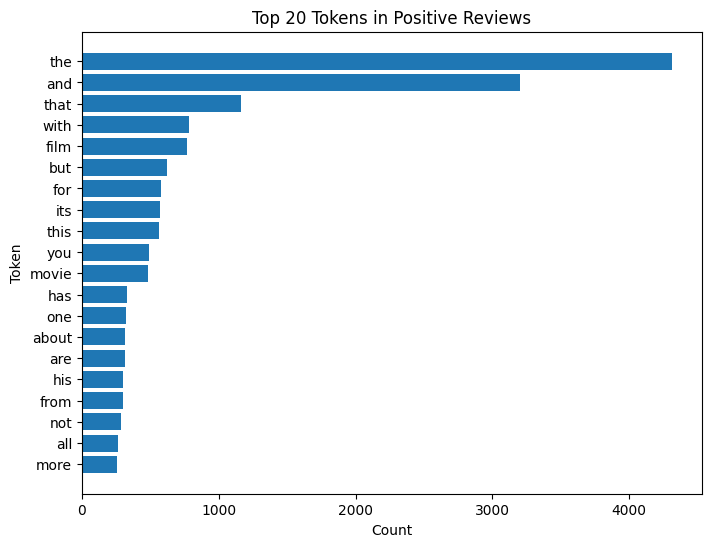


Top negative tokens:


,token,count
0,the,3982
1,and,2147
2,that,1043
3,movie,671
4,this,628
5,for,589
6,but,581
7,film,545
8,with,537
9,its,513



Top positive tokens:


,token,count
0,the,4316
1,and,3202
2,that,1163
3,with,784
4,film,770
5,but,623
6,for,575
7,its,574
8,this,567
9,you,488



Point-biserial correlation between review length and sentiment 0.0075
p-value: 0.46


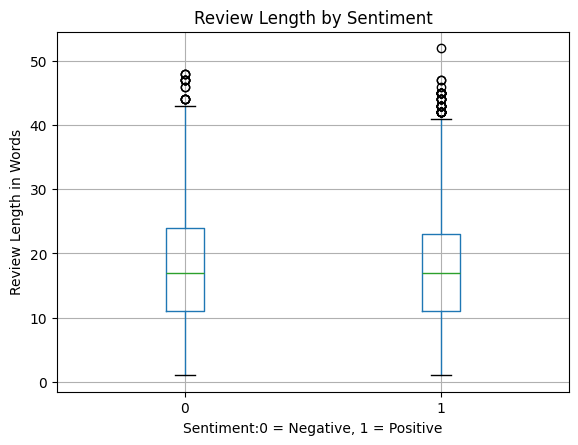

In [ ]:

import matplotlib.pyplot as plt
from collections import Counter
from scipy.stats import pointbiserialr

# Visualize class distribution
label_names = {0: "Negative", 1: "Positive"}

class_counts = df["sentiment"].map(label_names).value_counts()
class_counts.plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.show()

print("Class counts:")
print(class_counts)

#review length descriptive statistics
length_stats=df["review_length"].describe()
iqr=df["review_length"].quantile(0.75) - df["review_length"].quantile(0.25)
print("\nReview length statistics:")
print(length_stats)
print("IQR:", iqr)

#Most frequent tokens by sentiment class
def plot_top_tokens(data, sentiment_value, title, top_n=20):
    text = " ".join(data.loc[data["sentiment"] == sentiment_value, "cleaned_review"])
    tokens = [t for t in text.split() if len(t) > 2]
    counts = Counter(tokens).most_common(top_n)

    token_df = pd.DataFrame(counts, columns=["token", "count"])
    token_df = token_df.sort_values("count")

    plt.figure(figsize=(8, 6))
    plt.barh(token_df["token"], token_df["count"])
    plt.title(title)
    plt.xlabel("Count")
    plt.ylabel("Token")
    plt.show()
    return token_df.sort_values("count", ascending=False)

negative_tokens = plot_top_tokens(df, 0, "Top 20 Tokens in Negative Reviews")
positive_tokens = plot_top_tokens(df, 1, "Top 20 Tokens in Positive Reviews")

print("\nTop negative tokens:")
display(negative_tokens.head(10))
print("\nTop positive tokens:")
display(positive_tokens.head(10))

#correlation between review length and sentiment
corr, p_value = pointbiserialr(df["sentiment"], df["review_length"])
print("\nPoint-biserial correlation between review length and sentiment", round(corr,4))
print("p-value:", round(p_value,4))

df.boxplot(column="review_length", by="sentiment")
plt.title("Review Length by Sentiment")
plt.suptitle("")
plt.xlabel("Sentiment:0 = Negative, 1 = Positive")
plt.ylabel("Review Length in Words")
plt.show()


## Part 3 – Baseline Traditional Models


1. **Logistic Regression & SVM**  
    - Train at least two linear models on your TF-IDF features.  
    - Use cross-validation (≥ 5 folds) on the training set to tune at least one hyperparameter.
    

In [ ]:

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

# Logistic Regression
logreg = LogisticRegression(max_iter=1000, random_state=42)
svm=LinearSVC(random_state=42)

logreg_scores = cross_val_score(logreg, X_train_tfidf,y_train, cv =5, scoring="accuracy")

# SVM
svm_scores = cross_val_score(svm, X_train_tfidf, y_train,cv=5, scoring="accuracy")

cv_results=pd.DataFrame({
    "Model":["Logistic Regression", "Linear SVM"],
    "CV Scores": [logreg_scores, svm_scores],
    "Mean CV Accuracy":[logreg_scores.mean(), svm_scores.mean()]
})


display(cv_results)


,Model,CV Scores,Mean CV Accuracy
0,Logistic Regression,"[0.7769830949284785, 0.7698309492847855, 0.771...",0.772692
1,Linear SVM,"[0.7620286085825748, 0.7620286085825748, 0.764...",0.759428


In [ ]:
from sklearn.model_selection import GridSearchCV

# Tune hyperparameter C for Logistic Regression using 5-fold CV
param_grid = {"C": [0.01, 0.1, 1, 10, 100]}
grid_search = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)
grid_search.fit(X_train_tfidf, y_train)

print("Best C value:", grid_search.best_params_["C"])
print("Best CV Accuracy:", round(grid_search.best_score_, 4))

# Use best C to refit logreg
logreg = grid_search.best_estimator_

Best C value: 1
Best CV Accuracy: 0.7727


In [ ]:

logreg.fit(X_train_tfidf, y_train)
svm.fit(X_train_tfidf, y_train)

logreg_val_pred = logreg.predict(X_val_tfidf)
svm_val_pred = svm.predict(X_val_tfidf)

val_results = pd.DataFrame({
    "Model": ["Logistic Regression", "Linear SVM"],
    "Validation Accuracy":[
        accuracy_score(y_val, logreg_val_pred),
        accuracy_score(y_val, svm_val_pred)
    ]
})

display(val_results)

# Print accuracy for both models
print("Logistic Regression Validation Report")
print(classification_report(y_val, logreg_val_pred))

print("Linear SVM Validation Report")
print(classification_report(y_val, svm_val_pred))

best_model = svm
test_pred =best_model.predict(X_test_tfidf)
print("Final Test Accuracy:", accuracy_score(y_test, test_pred))
print("Final Test Classification Report")
print(classification_report(y_test, test_pred))


,Model,Validation Accuracy
0,Logistic Regression,0.783559
1,Linear SVM,0.785640


Logistic Regression Validation Report
              precision    recall  f1-score   support

           0       0.78      0.77      0.78       465
           1       0.79      0.79      0.79       496

    accuracy                           0.78       961
   macro avg       0.78      0.78      0.78       961
weighted avg       0.78      0.78      0.78       961

Linear SVM Validation Report
              precision    recall  f1-score   support

           0       0.77      0.79      0.78       465
           1       0.80      0.78      0.79       496

    accuracy                           0.79       961
   macro avg       0.79      0.79      0.79       961
weighted avg       0.79      0.79      0.79       961

Final Test Accuracy: 0.7598752598752598
Final Test Classification Report
              precision    recall  f1-score   support

           0       0.75      0.76      0.75       465
           1       0.77      0.76      0.77       497

    accuracy                           0.7

2. **Random Forest & Gradient Boosting**  
   - Train two tree-based models (e.g., Random Forest, XGBoost) on the same features.  
   - Report feature-importance for each and discuss any notable tokens.

In [ ]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_tfidf, y_train)

# Train Gradient Boosting
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train_tfidf, y_train)


GradientBoostingClassifier(random_state=42)

In [ ]:
# Evaluate both on test set
rf_pred  = rf.predict(X_test_tfidf)
rf_prob  = rf.predict_proba(X_test_tfidf)[:, 1]
gb_pred  = gb.predict(X_test_tfidf)
gb_prob  = gb.predict_proba(X_test_tfidf)[:, 1]

tree_results = pd.DataFrame([
    {
        "Model":     "Random Forest",
        "Accuracy":  round(accuracy_score(y_test, rf_pred), 4),
        "Precision": round(precision_score(y_test, rf_pred), 4),
        "Recall":    round(recall_score(y_test, rf_pred), 4),
        "F1":        round(f1_score(y_test, rf_pred), 4),
        "ROC-AUC":   round(roc_auc_score(y_test, rf_prob), 4)
    },
    {
        "Model":     "Gradient Boosting",
        "Accuracy":  round(accuracy_score(y_test, gb_pred), 4),
        "Precision": round(precision_score(y_test, gb_pred), 4),
        "Recall":    round(recall_score(y_test, gb_pred), 4),
        "F1":        round(f1_score(y_test, gb_pred), 4),
        "ROC-AUC":   round(roc_auc_score(y_test, gb_prob), 4)
    }
])
display(tree_results)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Random Forest,0.7328,0.7439,0.7364,0.7401,0.7982
1,Gradient Boosting,0.6310,0.6050,0.8229,0.6974,0.7208


In [ ]:
# Feature Importance
feature_names = vectorizer.get_feature_names_out()
top_n = 15

In [ ]:
# Random Forest
rf_importances = rf.feature_importances_
rf_top_idx     = np.argsort(rf_importances)[::-1][:top_n]
rf_top_words   = feature_names[rf_top_idx]
rf_top_vals    = rf_importances[rf_top_idx]

# Gradient Boosting
gb_importances = gb.feature_importances_
gb_top_idx     = np.argsort(gb_importances)[::-1][:top_n]
gb_top_words   = feature_names[gb_top_idx]
gb_top_vals    = gb_importances[gb_top_idx]

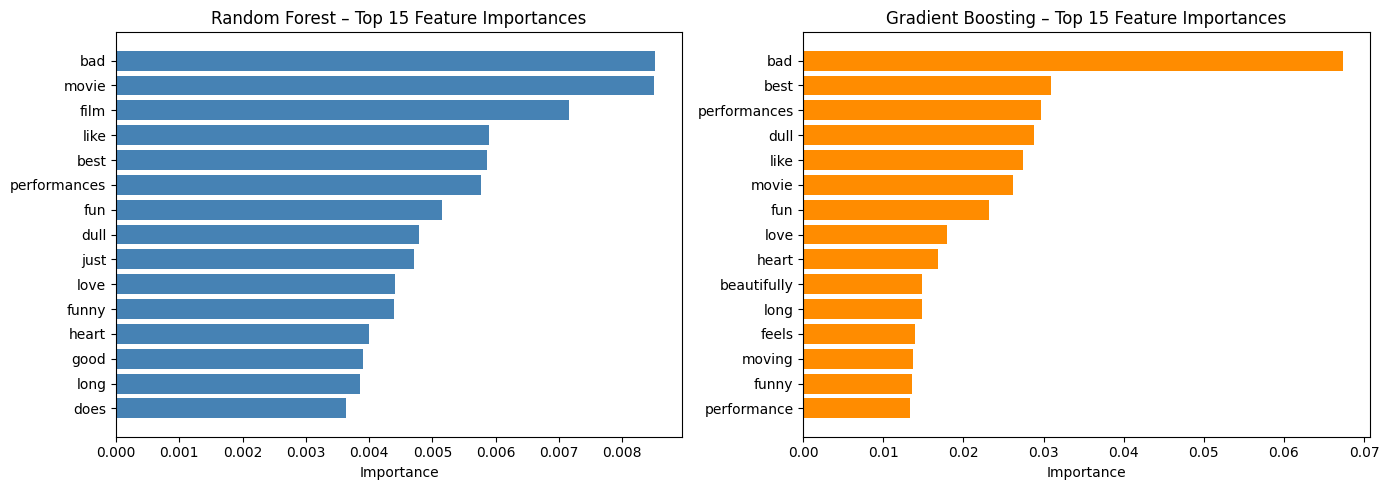

Notable tokens – Random Forest: ['bad', 'movie', 'film', 'like', 'best']
Notable tokens – Gradient Boosting: ['bad', 'best', 'performances', 'dull', 'like']


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(rf_top_words[::-1], rf_top_vals[::-1], color="steelblue")
axes[0].set_title("Random Forest – Top 15 Feature Importances")
axes[0].set_xlabel("Importance")

axes[1].barh(gb_top_words[::-1], gb_top_vals[::-1], color="darkorange")
axes[1].set_title("Gradient Boosting – Top 15 Feature Importances")
axes[1].set_xlabel("Importance")

plt.tight_layout()
plt.show()

# Discussion
print("Notable tokens – Random Forest:", list(rf_top_words[:5]))
print("Notable tokens – Gradient Boosting:", list(gb_top_words[:5]))

3. **Evaluation Metrics**  
   - Compute accuracy, precision, recall, F1-score, and ROC-AUC on the **held-out test set**.  
   - Present all results in a single comparison table.

In [ ]:
# Generate test predictions and probabilities for Logistic Regression and SVM
logreg_pred = logreg.predict(X_test_tfidf)
logreg_prob = logreg.predict_proba(X_test_tfidf)[:, 1]

svm_pred = svm.predict(X_test_tfidf)

# Comparison Table
all_traditional = pd.DataFrame([
    {"Model": "Logistic Regression",
     "Accuracy": round(accuracy_score(y_test, logreg_pred), 4),
     "Precision": round(precision_score(y_test, logreg_pred), 4),
     "Recall": round(recall_score(y_test, logreg_pred), 4),
     "F1": round(f1_score(y_test, logreg_pred), 4),
     "ROC-AUC": round(roc_auc_score(y_test, logreg_prob), 4)},
    {"Model": "Linear SVM",
     "Accuracy": round(accuracy_score(y_test, svm_pred), 4),
     "Precision": round(precision_score(y_test, svm_pred), 4),
     "Recall": round(recall_score(y_test, svm_pred), 4),
     "F1": round(f1_score(y_test, svm_pred), 4),
     "ROC-AUC": round(roc_auc_score(y_test, svm.decision_function(X_test_tfidf)), 4)},
    {"Model": "Random Forest",
     "Accuracy": round(accuracy_score(y_test, rf_pred), 4),
     "Precision": round(precision_score(y_test, rf_pred), 4),
     "Recall": round(recall_score(y_test, rf_pred), 4),
     "F1": round(f1_score(y_test, rf_pred), 4),
     "ROC-AUC": round(roc_auc_score(y_test, rf_prob), 4)},
    {"Model": "Gradient Boosting",
     "Accuracy": round(accuracy_score(y_test, gb_pred), 4),
     "Precision": round(precision_score(y_test, gb_pred), 4),
     "Recall": round(recall_score(y_test, gb_pred), 4),
     "F1": round(f1_score(y_test, gb_pred), 4),
     "ROC-AUC": round(roc_auc_score(y_test, gb_prob), 4)},
])
print("=== Part 3 – All Traditional Models Comparison ===")
display(all_traditional.sort_values("F1", ascending=False).reset_index(drop=True))

=== Part 3 – All Traditional Models Comparison ===


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.7713,0.7721,0.7907,0.7813,0.8539
1,Linear SVM,0.7599,0.7737,0.7565,0.7650,0.8403
2,Random Forest,0.7328,0.7439,0.7364,0.7401,0.7982
3,Gradient Boosting,0.6310,0.6050,0.8229,0.6974,0.7208


## Part 4 – Neural Network Models


1. **Simple Feed-Forward**  
    - Build an embedding layer + a dense MLP classifier.  
    - Ensure you freeze vs. unfreeze embeddings in separate runs.

2. **Convolutional Text Classifier**  
   - Implement a 1D-CNN architecture (Conv + Pooling) for sequence data.  
   - Justify your choice of kernel sizes and number of filters.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/5
241/241 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.5090 - loss: 0.6934 - val_accuracy: 0.5203 - val_loss: 0.6922
Epoch 2/5
241/241 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5375 - loss: 0.6888 - val_accuracy: 0.5505 - val_loss: 0.6876
Epoch 3/5
241/241 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5642 - loss: 0.6780 - val_accuracy: 0.5109 - val_loss: 0.6928
Epoch 4/5
241/241 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5906 - loss: 0.6641 - val_accuracy: 0.5359 - val_loss: 0.6885
Epoch 1/5
241/241 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.6005 - loss: 0.6451 - val_accuracy: 0.7575 - val_loss: 0.5085
Epoch 2/5
241/241 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8733 - loss: 0.3047 - val_accuracy: 0.7742 - val_loss: 0.4880
Epoch 3/5
241/241 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9854 - loss: 0.0557 - val_accuracy: 0.7773 - val_loss: 0.6165
Epoch 4/5
241/241 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9983 - loss: 0.0121 - val_accuracy: 0.7700 - 

,Model,Accuracy,Precision,Recall,F1 Score
0,MLP Frozen Embedding,0.547817,0.544413,0.764588,0.635983
1,MLP Trainable Embedding,0.764033,0.770000,0.774648,0.772317
2,CNN Text Classifier,0.794179,0.796040,0.808853,0.802395


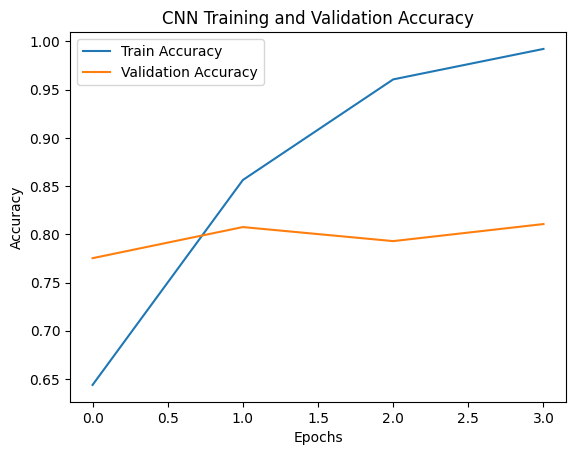

In [ ]:

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, Flatten, Dropout, Conv1D, GlobalMaxPooling1D
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

VOCAB_SIZE = min(MAX_WORDS, len(tokenizer.word_index)+1)
EMBED_DIM =64

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

def build_mlp_model(trainable_embedding=True):
  model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM, input_length=MAX_LEN, trainable=trainable_embedding),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

  model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
  return model

#Frozen embedding
mlp_frozen = build_mlp_model(trainable_embedding=False)
history_frozen = mlp_frozen.fit(
    X_train_seq,
    y_train,
    validation_data=(X_val_seq, y_val),
    epochs=5,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

#unfrozen/trainable_embedding
mlp_unfrozen = build_mlp_model(trainable_embedding=True)
history_unfrozen = mlp_unfrozen.fit(
    X_train_seq,
    y_train,
    validation_data=(X_val_seq, y_val),
    epochs=5,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

#Convolutional text classifier
cnn_model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM, input_length=MAX_LEN),
    Conv1D(filters=64, kernel_size=3, activation='relu'),
    GlobalMaxPooling1D(),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history_cnn = cnn_model.fit(
    X_train_seq,
    y_train,
    validation_data=(X_val_seq, y_val),
    epochs=5,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

def evaluate_neural_model(model, X, y, model_name):
    probs = model.predict(X).ravel()
    preds = (probs > 0.5).astype(int)

    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y, preds),
        "Precision": precision_score(y, preds),
        "Recall": recall_score(y, preds),
        "F1 Score": f1_score(y, preds)
    }

neural_results = pd.DataFrame([
    evaluate_neural_model(mlp_frozen, X_test_seq, y_test, "MLP Frozen Embedding"),
    evaluate_neural_model(mlp_unfrozen, X_test_seq, y_test, "MLP Trainable Embedding"),
    evaluate_neural_model(cnn_model, X_test_seq, y_test, "CNN Text Classifier")
])

display(neural_results)

#save neural models
mlp_frozen.save("mlp_forzen_embedding.keras")
mlp_unfrozen.save("mlp_trainable_embedding.keras")
cnn_model.save("cnn_text_classifier.keras")

#Plot training curves for CNN model
plt.plot(history_cnn.history["accuracy"], label="Train Accuracy")
plt.plot(history_cnn.history["val_accuracy"], label="Validation Accuracy")
plt.title("CNN Training and Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

kernel_size=3 captures trigram-level local patterns, which are effective for short sentiment phrases. filters=64 provides sufficient feature map capacity without overfitting given our ~7,600 training samples.

## Part 5 – Transfer Learning & Advanced Architectures


1. **Pre-trained Embeddings**  
    - Retrain one network using pre-trained GloVe (or FastText) embeddings.
    - Compare results against your from-scratch embedding runs.
    

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Download GloVe
!wget -q --show-progress https://nlp.stanford.edu/data/glove.6B.zip -O glove.6B.zip
!unzip -q glove.6B.zip -d glove/

GLOVE_PATH = "glove/glove.6B.100d.txt"
GLOVE_DIM  = 100

glove.6B.zip        100%[===================>] 822.24M  5.05MB/s    in 2m 39s  


In [ ]:
# Load GloVe into a dictionary
glove_dict = {}
with open(GLOVE_PATH, "r", encoding="utf-8") as f:
    for line in f:
        parts = line.split()
        word   = parts[0]
        vector = np.array(parts[1:], dtype="float32")
        glove_dict[word] = vector

print(f"Loaded {len(glove_dict):,} GloVe vectors (dim={GLOVE_DIM})")

Loaded 400,000 GloVe vectors (dim=100)


In [ ]:
# Build embedding matrix aligned with Keras tokenizer
embedding_matrix = np.zeros((VOCAB_SIZE, GLOVE_DIM))
hits, misses = 0, 0
for word, idx in tokenizer.word_index.items():
    if idx >= VOCAB_SIZE:
        continue
    vec = glove_dict.get(word)
    if vec is not None:
        embedding_matrix[idx] = vec
        hits += 1
    else:
        misses += 1

print(f"Words covered by GloVe: {hits}  |  Missing: {misses}")

Words covered by GloVe: 9880  |  Missing: 119


In [ ]:
# Build CNN model with frozen GloVe embeddings
def build_cnn_glove(trainable=False):
    model = Sequential([
        Embedding(
            input_dim=VOCAB_SIZE,
            output_dim=GLOVE_DIM,
            weights=[embedding_matrix],
            input_length=MAX_LEN,
            trainable=trainable          # False = frozen
        ),
        Conv1D(filters=64, kernel_size=3, activation="relu"),
        GlobalMaxPooling1D(),
        Dense(64, activation="relu"),
        Dropout(0.3),
        Dense(1, activation="sigmoid")
    ])
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model

early_stop = EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)

In [ ]:
# Frozen GloVe
cnn_glove_frozen = build_cnn_glove(trainable=False)
print("\n--- Training CNN with FROZEN GloVe embeddings ---")
history_glove_frozen = cnn_glove_frozen.fit(
    X_train_seq, y_train,
    validation_data=(X_val_seq, y_val),
    epochs=10, batch_size=32,
    callbacks=[early_stop], verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(



--- Training CNN with FROZEN GloVe embeddings ---
Epoch 1/10
241/241 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.6581 - loss: 0.6089 - val_accuracy: 0.6639 - val_loss: 0.5812
Epoch 2/10
241/241 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7806 - loss: 0.4687 - val_accuracy: 0.7836 - val_loss: 0.4654
Epoch 3/10
241/241 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8187 - loss: 0.4036 - val_accuracy: 0.7399 - val_loss: 0.5245
Epoch 4/10
241/241 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8490 - loss: 0.3466 - val_accuracy: 0.7888 - val_loss: 0.4554
Epoch 5/10
241/241 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8793 - loss: 0.2954 - val_accuracy: 0.7877 - val_loss: 0.4687
Epoch 6/10
241/241 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9083 - loss: 0.2304 - val_accuracy: 0.7856 - val_loss: 0.5048


In [ ]:
# Fine-tuned GloVe (trainable)
cnn_glove_tuned = build_cnn_glove(trainable=True)
print("\n--- Training CNN with TRAINABLE GloVe embeddings ---")
history_glove_tuned = cnn_glove_tuned.fit(
    X_train_seq, y_train,
    validation_data=(X_val_seq, y_val),
    epochs=10, batch_size=32,
    callbacks=[early_stop], verbose=1
)


--- Training CNN with TRAINABLE GloVe embeddings ---
Epoch 1/10
241/241 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.6779 - loss: 0.5842 - val_accuracy: 0.7867 - val_loss: 0.4690
Epoch 2/10
241/241 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8386 - loss: 0.3645 - val_accuracy: 0.8044 - val_loss: 0.4318
Epoch 3/10
241/241 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9160 - loss: 0.2192 - val_accuracy: 0.8200 - val_loss: 0.4554
Epoch 4/10
241/241 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9688 - loss: 0.0972 - val_accuracy: 0.8106 - val_loss: 0.5446


In [ ]:
# Evaluate and compare with Part-4 scratch models
def eval_keras_model(model, X, y, name):
    probs = model.predict(X, verbose=0).ravel()
    preds = (probs > 0.5).astype(int)
    return {
        "Model":     name,
        "Accuracy":  round(accuracy_score(y, preds), 4),
        "Precision": round(precision_score(y, preds), 4),
        "Recall":    round(recall_score(y, preds), 4),
        "F1":        round(f1_score(y, preds), 4)
    }

embedding_comparison = pd.DataFrame([
    eval_keras_model(mlp_frozen,      X_test_seq, y_test, "MLP (Scratch, Frozen)"),
    eval_keras_model(mlp_unfrozen,    X_test_seq, y_test, "MLP (Scratch, Trainable)"),
    eval_keras_model(cnn_model,       X_test_seq, y_test, "CNN (Scratch)"),
    eval_keras_model(cnn_glove_frozen, X_test_seq, y_test, "CNN (GloVe, Frozen)"),
    eval_keras_model(cnn_glove_tuned,  X_test_seq, y_test, "CNN (GloVe, Fine-tuned)"),
])
print("\n=== Embedding Strategy Comparison ===")
display(embedding_comparison)


=== Embedding Strategy Comparison ===


,Model,Accuracy,Precision,Recall,F1
0,"MLP (Scratch, Frozen)",0.5478,0.5444,0.7646,0.6360
1,"MLP (Scratch, Trainable)",0.7640,0.7700,0.7746,0.7723
2,CNN (Scratch),0.7942,0.7960,0.8089,0.8024
3,"CNN (GloVe, Frozen)",0.8004,0.8068,0.8068,0.8068
4,"CNN (GloVe, Fine-tuned)",0.7942,0.7694,0.8592,0.8118


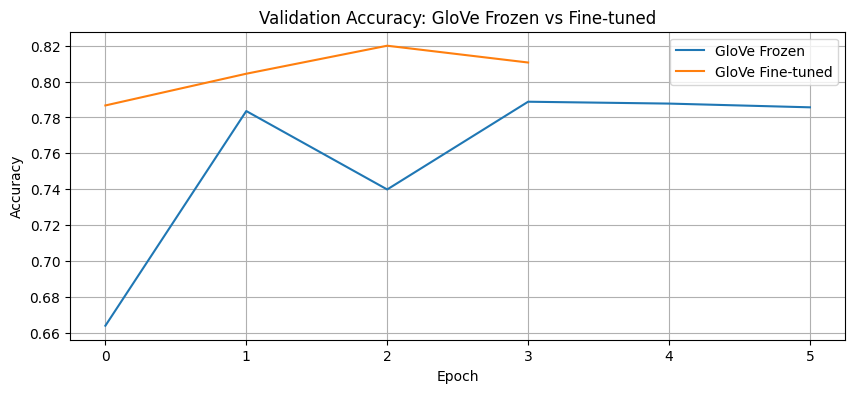

In [ ]:
# training accuracy comparison
plt.figure(figsize=(10, 4))
plt.plot(history_glove_frozen.history["val_accuracy"], label="GloVe Frozen")
plt.plot(history_glove_tuned.history["val_accuracy"],  label="GloVe Fine-tuned")
plt.title("Validation Accuracy: GloVe Frozen vs Fine-tuned")
plt.xlabel("Epoch"); plt.ylabel("Accuracy")
plt.legend(); plt.grid(True); plt.show()


In [ ]:
# Save models
cnn_glove_frozen.save("cnn_glove_frozen.keras")
cnn_glove_tuned.save("cnn_glove_tuned.keras")

2. **Transformer Fine-Tuning**  
   - Fine-tune a BERT-family model on the training data.  
   - Clearly outline your training hyperparameters (learning rate, batch size, epochs).


In [ ]:
# DistilBERT Fine-Tuning

!pip install transformers torch -q

import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification
from sklearn.metrics import accuracy_score, f1_score, classification_report
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
# Hyperparameters
MAX_BERT_LEN  = 128   # subword sequence length
BATCH_SIZE    = 32    # mini-batch size
LEARNING_RATE = 2e-5  # AdamW learning rate
EPOCHS        = 3     # max training epochs
PATIENCE      = 1     # early-stopping patience

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")


Device: cuda


In [ ]:
# Tokenizer
bert_tok = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
# PyTorch Dataset
class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.enc = tokenizer(
            list(texts),
            max_length=max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        self.labels = torch.tensor(labels.values, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids":      self.enc["input_ids"][idx],
            "attention_mask": self.enc["attention_mask"][idx],
            "labels":         self.labels[idx]
        }

print("Tokenizing splits...")
train_ds = SentimentDataset(train_df["review"], y_train, bert_tok, MAX_BERT_LEN)
val_ds   = SentimentDataset(val_df["review"],   y_val,   bert_tok, MAX_BERT_LEN)
test_ds  = SentimentDataset(test_df["review"],  y_test,  bert_tok, MAX_BERT_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE)

Tokenizing splits...


In [ ]:
# Load pre-trained model
bert_model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased", num_labels=2
).to(device)

optimizer = AdamW(bert_model.parameters(), lr=LEARNING_RATE)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
# Training loop with early stopping
train_losses, val_accs = [], []
best_val_acc, patience_count = 0, 0

for epoch in range(EPOCHS):
    # Train
    bert_model.train()
    epoch_loss = 0
    for batch in train_loader:
        optimizer.zero_grad()
        out  = bert_model(
            input_ids      = batch["input_ids"].to(device),
            attention_mask = batch["attention_mask"].to(device),
            labels         = batch["labels"].to(device)
        )
        out.loss.backward()
        optimizer.step()
        epoch_loss += out.loss.item()

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)

    # Validate
    bert_model.eval()
    all_preds, all_true = [], []
    with torch.no_grad():
        for batch in val_loader:
            logits = bert_model(
                input_ids      = batch["input_ids"].to(device),
                attention_mask = batch["attention_mask"].to(device)
            ).logits
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_true.extend(batch["labels"].numpy())

    val_acc = accuracy_score(all_true, all_preds)
    val_accs.append(val_acc)
    print(f"Epoch {epoch+1}/{EPOCHS}  |  Train Loss: {avg_loss:.4f}  |  Val Acc: {val_acc:.4f}")

    # Early stopping
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        bert_model.save_pretrained("best_bert_model")
        bert_tok.save_pretrained("best_bert_model")
        patience_count = 0
        print("  ✓ Best model saved.")
    else:
        patience_count += 1
        if patience_count >= PATIENCE:
            print("  Early stopping triggered.")
            break


Epoch 1/3  |  Train Loss: 0.3773  |  Val Acc: 0.8887


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ Best model saved.
Epoch 2/3  |  Train Loss: 0.1778  |  Val Acc: 0.8959


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ Best model saved.
Epoch 3/3  |  Train Loss: 0.0893  |  Val Acc: 0.9053


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ Best model saved.


In [ ]:
# Load best checkpoint & evaluate on test set
best_bert = DistilBertForSequenceClassification.from_pretrained("best_bert_model").to(device)
best_bert.eval()

bert_preds_list, bert_probs_list = [], []
with torch.no_grad():
    for batch in test_loader:
        logits = best_bert(
            input_ids      = batch["input_ids"].to(device),
            attention_mask = batch["attention_mask"].to(device)
        ).logits
        probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
        preds = (probs > 0.5).astype(int)
        bert_preds_list.extend(preds)
        bert_probs_list.extend(probs)

bert_preds = np.array(bert_preds_list)
bert_probs = np.array(bert_probs_list)

print("\n=== DistilBERT Test Results ===")
print(f"Accuracy : {accuracy_score(y_test, bert_preds):.4f}")
print(f"F1 Score : {f1_score(y_test, bert_preds):.4f}")
print(classification_report(y_test, bert_preds, target_names=["Negative", "Positive"]))


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]


=== DistilBERT Test Results ===
Accuracy : 0.8825
F1 Score : 0.8853
              precision    recall  f1-score   support

    Negative       0.87      0.89      0.88       465
    Positive       0.89      0.88      0.89       497

    accuracy                           0.88       962
   macro avg       0.88      0.88      0.88       962
weighted avg       0.88      0.88      0.88       962



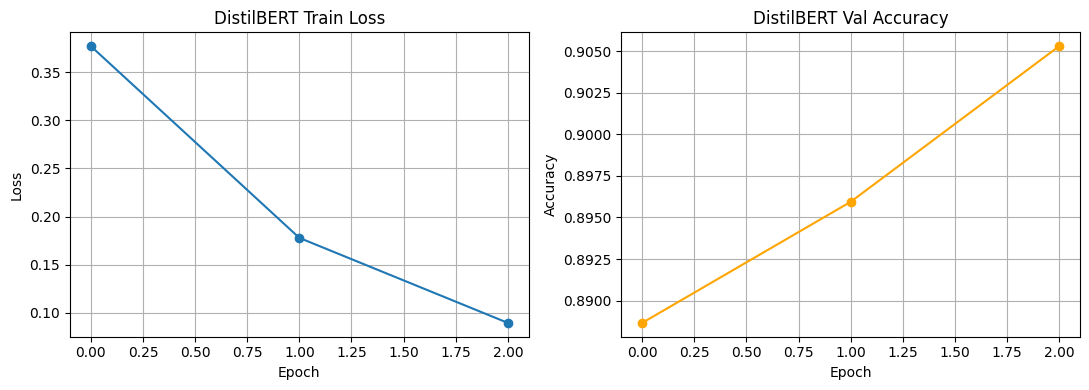

In [ ]:
# Training curves
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(train_losses, marker="o"); axes[0].set_title("DistilBERT Train Loss")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].grid(True)
axes[1].plot(val_accs, marker="o", color="orange"); axes[1].set_title("DistilBERT Val Accuracy")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].grid(True)
plt.tight_layout(); plt.show()

## Part 6 – Hyperparameter Optimization


1. **Search Strategy**  
    - Use a library (e.g., Keras Tuner, Optuna) to optimize at least two hyperparameters of one deep model.
    - Describe your search space and stopping criteria.
    

In [ ]:
# Hyperparameter Optimization with Keras Tuner
!pip install keras-tuner -q

import keras_tuner as kt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 11.3 MB/s eta 0:00:00


In [ ]:
# Search space (at least 2 hyperparameters as required):
# - filters      : {32, 64, 128}
# - kernel_size  : {3, 5}
# - dense_units  : {32, 64, 96, 128}
# - dropout_rate : {0.1, 0.2, 0.3, 0.4, 0.5}
#
# Stopping criteria: EarlyStopping(patience=2) inside each trial;
#                    RandomSearch stops after max_trials=10

def build_model(hp):
    filters     = hp.Choice("filters",      [32, 64, 128])
    kernel_size = hp.Choice("kernel_size",  [3, 5])
    dense_units = hp.Int("dense_units",     min_value=32, max_value=128, step=32)
    dropout_rate= hp.Float("dropout_rate",  min_value=0.1, max_value=0.5, step=0.1)

    model = Sequential([
        Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM, input_length=MAX_LEN),
        Conv1D(filters=filters, kernel_size=kernel_size, activation="relu"),
        GlobalMaxPooling1D(),
        Dense(dense_units, activation="relu"),
        Dropout(dropout_rate),
        Dense(1, activation="sigmoid")
    ])
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

tuner = kt.RandomSearch(
    build_model,
    objective="val_accuracy",
    max_trials=10,
    seed=42,
    project_name="cnn_sentiment_tuning"
)

tuner.search(
    X_train_seq, y_train,
    epochs=10,
    validation_data=(X_val_seq, y_val),
    callbacks=[EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)],
    verbose=1
)

print("\n=== Best Hyperparameter Configuration ===")
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"  filters      : {best_hp.get('filters')}")
print(f"  kernel_size  : {best_hp.get('kernel_size')}")
print(f"  dense_units  : {best_hp.get('dense_units')}")
print(f"  dropout_rate : {best_hp.get('dropout_rate')}")

tuner.results_summary()

Trial 10 Complete [00h 00m 10s]
val_accuracy: 0.8116545081138611

Best val_accuracy So Far: 0.8220603466033936
Total elapsed time: 00h 02m 23s

=== Best Hyperparameter Configuration ===
  filters      : 64
  kernel_size  : 3
  dense_units  : 64
  dropout_rate : 0.30000000000000004
Results summary
Results in ./cnn_sentiment_tuning
Showing 10 best trials
Objective(name="val_accuracy", direction="max")

Trial 04 summary
Hyperparameters:
filters: 64
kernel_size: 3
dense_units: 64
dropout_rate: 0.30000000000000004
Score: 0.8220603466033936

Trial 00 summary
Hyperparameters:
filters: 64
kernel_size: 3
dense_units: 64
dropout_rate: 0.2
Score: 0.819979190826416

Trial 06 summary
Hyperparameters:
filters: 32
kernel_size: 3
dense_units: 96
dropout_rate: 0.4
Score: 0.8189386129379272

Trial 07 summary
Hyperparameters:
filters: 128
kernel_size: 3
dense_units: 32
dropout_rate: 0.2
Score: 0.8147763013839722

Trial 03 summary
Hyperparameters:
filters: 128
kernel_size: 3
dense_units: 128
dropout_rate:

2. **Results Analysis**  
   - Report the best hyperparameter configuration found.  
   - Plot validation-loss (or metric) vs. trials to illustrate tuning behavior.


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, classification_report


In [ ]:
# Retrieve and retrain best model
best_cnn = tuner.get_best_models(num_models=1)[0]
best_cnn.build(input_shape=(None, MAX_LEN))
best_cnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 16 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 50, 64)         │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 48, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 64)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 656,577 (2.50 MB)

 Trainable params: 656,577 (2.50 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Test set evaluation
cnn_tu_prob = best_cnn.predict(X_test_seq, verbose=0).ravel()
cnn_tu_pred = (cnn_tu_prob > 0.5).astype(int)

print("=== Tuned CNN – Test Set Results ===")
print(f"Accuracy : {accuracy_score(y_test, cnn_tu_pred):.4f}")
print(f"F1 Score : {f1_score(y_test, cnn_tu_pred):.4f}")
print(classification_report(y_test, cnn_tu_pred, target_names=["Negative", "Positive"]))


=== Tuned CNN – Test Set Results ===
Accuracy : 0.7963
F1 Score : 0.8044
              precision    recall  f1-score   support

    Negative       0.79      0.78      0.79       465
    Positive       0.80      0.81      0.80       497

    accuracy                           0.80       962
   macro avg       0.80      0.80      0.80       962
weighted avg       0.80      0.80      0.80       962



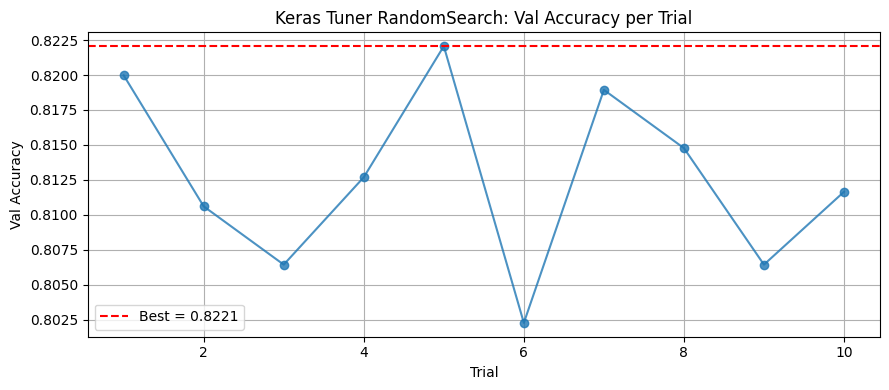

In [ ]:
# Plot: val_accuracy across trials
trial_accs = []
for trial in tuner.oracle.trials.values():
    score = trial.score
    if score is not None:
        trial_accs.append(score)

plt.figure(figsize=(9, 4))
plt.plot(range(1, len(trial_accs)+1), trial_accs, marker="o", alpha=0.8)
plt.axhline(max(trial_accs), color="red", linestyle="--",
            label=f"Best = {max(trial_accs):.4f}")
plt.title("Keras Tuner RandomSearch: Val Accuracy per Trial")
plt.xlabel("Trial"); plt.ylabel("Val Accuracy")
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()


In [ ]:
# Best config summary table
best_config = pd.DataFrame([{
    "filters":       best_hp.get("filters"),
    "kernel_size":   best_hp.get("kernel_size"),
    "dense_units":   best_hp.get("dense_units"),
    "dropout_rate":  best_hp.get("dropout_rate"),
    "Val Accuracy":  round(max(trial_accs), 4),
    "Test Accuracy": round(accuracy_score(y_test, cnn_tu_pred), 4),
    "Test F1":       round(f1_score(y_test, cnn_tu_pred), 4)
}])
print("=== Best Configuration Summary ===")
display(best_config)


=== Best Configuration Summary ===


,filters,kernel_size,dense_units,dropout_rate,Val Accuracy,Test Accuracy,Test F1
0,64,3,64,0.3,0.8221,0.7963,0.8044


In [ ]:
# Save
best_cnn.save("best_cnn_tuned.keras")
print("best_cnn_tuned.keras saved.")

best_cnn_tuned.keras saved.


## Part 7 – Final Comparison & Error Analysis


1. **Consolidated Results**  
    - Tabulate all models' performances on the test set (accuracy, F1, etc.)
    - Identify the best-performing model and its hyperparameters.
    

In [ ]:
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score, roc_auc_score,
                              classification_report)
import pandas as pd
import numpy as np

In [ ]:
def get_all_metrics(y_true, y_pred, y_prob, name):
    y_true = np.array(y_true)
    return {
        "Model":     name,
        "Accuracy":  round(accuracy_score(y_true, y_pred),  4),
        "Precision": round(precision_score(y_true, y_pred), 4),
        "Recall":    round(recall_score(y_true, y_pred),    4),
        "F1":        round(f1_score(y_true, y_pred),        4),
        "ROC-AUC":   round(roc_auc_score(y_true, y_prob),   4)
    }

def keras_preds_probs(model, X):
    p = model.predict(X, verbose=0).ravel()
    return (p > 0.5).astype(int), p

In [ ]:
# Traditional models
logreg_pred = logreg.predict(X_test_tfidf)
logreg_prob = logreg.predict_proba(X_test_tfidf)[:, 1]

svm_pred    = svm.predict(X_test_tfidf)
svm_prob    = svm.decision_function(X_test_tfidf)

In [ ]:
# Neural models
mlp_f_pred,  mlp_f_prob  = keras_preds_probs(mlp_frozen,       X_test_seq)
mlp_t_pred,  mlp_t_prob  = keras_preds_probs(mlp_unfrozen,     X_test_seq)
cnn_s_pred,  cnn_s_prob  = keras_preds_probs(cnn_model,        X_test_seq)


In [ ]:
# Transfer learning models
cnn_gf_pred, cnn_gf_prob = keras_preds_probs(cnn_glove_frozen, X_test_seq)
cnn_gt_pred, cnn_gt_prob = keras_preds_probs(cnn_glove_tuned,  X_test_seq)


In [ ]:
# Tuned model
cnn_tu_pred, cnn_tu_prob = keras_preds_probs(best_cnn,         X_test_seq)


In [ ]:
rows = [
    get_all_metrics(y_test, logreg_pred,  logreg_prob,  "Logistic Regression"),
    get_all_metrics(y_test, svm_pred,     svm_prob,     "Linear SVM"),
    get_all_metrics(y_test, rf_pred,      rf_prob,      "Random Forest"),
    get_all_metrics(y_test, gb_pred,      gb_prob,      "Gradient Boosting"),
    get_all_metrics(y_test, mlp_f_pred,   mlp_f_prob,   "MLP (Frozen Embedding)"),
    get_all_metrics(y_test, mlp_t_pred,   mlp_t_prob,   "MLP (Trainable Embedding)"),
    get_all_metrics(y_test, cnn_s_pred,   cnn_s_prob,   "CNN (Scratch)"),
    get_all_metrics(y_test, cnn_gf_pred,  cnn_gf_prob,  "CNN (GloVe Frozen)"),
    get_all_metrics(y_test, cnn_gt_pred,  cnn_gt_prob,  "CNN (GloVe Fine-tuned)"),
    get_all_metrics(y_test, cnn_tu_pred,  cnn_tu_prob,  "CNN (Keras Tuner)"),
    get_all_metrics(y_test, bert_preds,   bert_probs,   "DistilBERT"),
]

results_df = (pd.DataFrame(rows)
              .sort_values("F1", ascending=False)
              .reset_index(drop=True))

print("=== Consolidated Model Comparison – Test Set ===")
display(results_df.style.highlight_max(
    subset=["Accuracy","Precision","Recall","F1","ROC-AUC"],
    color="lightgreen"
))

best_model_name = results_df.iloc[0]["Model"]
print(f"\nTop overall model : {best_model_name}")
print(f"Top traditional   : {results_df[results_df['Model'].isin(['Logistic Regression','Linear SVM'])].iloc[0]['Model']}")
print(f"Top neural        : {results_df[~results_df['Model'].isin(['Logistic Regression','Linear SVM','DistilBERT'])].iloc[0]['Model']}")


=== Consolidated Model Comparison – Test Set ===


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,DistilBERT,0.882500,0.893400,0.877300,0.885300,0.956000
1,CNN (GloVe Fine-tuned),0.794200,0.769400,0.859200,0.811800,0.888400
2,CNN (GloVe Frozen),0.800400,0.806800,0.806800,0.806800,0.880900
3,CNN (Keras Tuner),0.796300,0.798000,0.810900,0.804400,0.874100
4,CNN (Scratch),0.794200,0.796000,0.808900,0.802400,0.879300
5,Logistic Regression,0.771300,0.772100,0.790700,0.781300,0.853900
6,MLP (Trainable Embedding),0.764000,0.770000,0.774600,0.772300,0.855300
7,Linear SVM,0.759900,0.773700,0.756500,0.765000,0.840300
8,Random Forest,0.732800,0.743900,0.736400,0.740100,0.798200
9,Gradient Boosting,0.631000,0.605000,0.822900,0.697400,0.720800



Top overall model : DistilBERT
Top traditional   : Logistic Regression
Top neural        : CNN (GloVe Fine-tuned)


2. **Statistical Significance**  
   - Perform a significance test (e.g., McNemar’s test) between your best two models.  

In [ ]:
# McNemar's Test (top-2 models)

!pip install statsmodels -q
from statsmodels.stats.contingency_tables import mcnemar
import pandas as pd
import numpy as np


In [ ]:
# Map all model names to their test predictions
model_pred_map = {
    "Logistic Regression":       logreg_pred,
    "Linear SVM":                svm_pred,
    "Random Forest":             rf_pred,
    "Gradient Boosting":         gb_pred,
    "MLP (Frozen Embedding)":    mlp_f_pred,
    "MLP (Trainable Embedding)": mlp_t_pred,
    "CNN (Scratch)":             cnn_s_pred,
    "CNN (GloVe Frozen)":        cnn_gf_pred,
    "CNN (GloVe Fine-tuned)":    cnn_gt_pred,
    "CNN (Keras Tuner)":         cnn_tu_pred,
    "DistilBERT":                bert_preds,
}


In [ ]:
# Pick top-2 from consolidated results table
top1_name = results_df.iloc[0]["Model"]
top2_name = results_df.iloc[1]["Model"]
print(f"Comparing: '{top1_name}'  vs  '{top2_name}'")

preds_A = np.array(model_pred_map[top1_name])
preds_B = np.array(model_pred_map[top2_name])
y_true  = np.array(y_test)


Comparing: 'DistilBERT'  vs  'CNN (GloVe Fine-tuned)'


In [ ]:
# Build 2×2 contingency table
both_right   = np.sum((preds_A == y_true) & (preds_B == y_true))
A_right_only = np.sum((preds_A == y_true) & (preds_B != y_true))
B_right_only = np.sum((preds_A != y_true) & (preds_B == y_true))
both_wrong   = np.sum((preds_A != y_true) & (preds_B != y_true))

table = np.array([[both_right,   A_right_only],
                  [B_right_only, both_wrong]])

ct_df = pd.DataFrame(
    table,
    index   =[f"{top1_name} Correct", f"{top1_name} Wrong"],
    columns =[f"{top2_name} Correct", f"{top2_name} Wrong"]
)
print("\nMcNemar Contingency Table:")
display(ct_df)

result = mcnemar(table, exact=True)
print(f"\nMcNemar Statistic : {result.statistic:.4f}")
print(f"p-value           : {result.pvalue:.4f}")

if result.pvalue < 0.05:
    print("→ Statistically SIGNIFICANT difference (p < 0.05)")
    print(f"  '{top1_name}' performs significantly better.")
else:
    print("→ No statistically significant difference (p ≥ 0.05)")


McNemar Contingency Table:


,CNN (GloVe Fine-tuned) Correct,CNN (GloVe Fine-tuned) Wrong
DistilBERT Correct,714,135
DistilBERT Wrong,50,63



McNemar Statistic : 50.0000
p-value           : 0.0000
→ Statistically SIGNIFICANT difference (p < 0.05)
  'DistilBERT' performs significantly better.


3. **Error Analysis**  
   - Identify at least 20 examples your best model misclassified.  
   - For a sample of 5, provide the raw text, predicted vs. true label, and a short discussion of each error—what linguistic artifact might have confused the model?

In [ ]:
# Error Analysis

import pandas as pd
import numpy as np

# Use best model predictions (DistilBERT or top-ranked model)
best_pred_final = np.array(model_pred_map[top1_name])
best_prob_final = bert_probs if top1_name == "DistilBERT" else cnn_tu_prob

y_true_arr   = np.array(y_test)
test_reviews = test_df["review"].reset_index(drop=True).values
test_cleaned = test_df["cleaned_review"].reset_index(drop=True).values


In [ ]:
# Find all misclassified examples
wrong_idx = np.where(best_pred_final != y_true_arr)[0]
print(f"Total misclassified by {top1_name}: {len(wrong_idx)} / {len(y_true_arr)}")
print(f"Error rate: {len(wrong_idx)/len(y_true_arr)*100:.1f}%")


Total misclassified by DistilBERT: 113 / 962
Error rate: 11.7%


In [ ]:
# 20 misclassified examples table
sample = wrong_idx[:20]

error_df = pd.DataFrame({
    "Review":      test_reviews[sample],
    "True Label":  ["Positive" if l==1 else "Negative" for l in y_true_arr[sample]],
    "Predicted":   ["Positive" if l==1 else "Negative" for l in best_pred_final[sample]],
    "Confidence":  np.round(best_prob_final[sample], 4)
})

print(f"\n=== 20 Misclassified Examples ===")
display(error_df)


=== 20 Misclassified Examples ===


,Review,True Label,Predicted,Confidence
0,the closest thing to the experience of space t...,Positive,Negative,0.3472
1,a pleasurably jacked-up piece of action moviem...,Positive,Negative,0.0096
2,fred schepisi 's film is paced at a speed that...,Negative,Positive,0.6012
3,"i 'm not suggesting that you actually see it ,...",Negative,Positive,0.8921
4,essentially a collection of bits -- and they '...,Positive,Negative,0.0669
5,this is historical filmmaking without the balm...,Positive,Negative,0.0354
6,imagine susan sontag falling in love with howa...,Negative,Positive,0.8648
7,it does n't flinch from its unsettling prognos...,Negative,Positive,0.9507
8,skip work to see it at the first opportunity .,Positive,Negative,0.0121
9,"in between all the emotional seesawing , it 's...",Negative,Positive,0.6412


In [ ]:
# Error type breakdown
fp = np.sum((best_pred_final == 1) & (y_true_arr == 0))  # False Positive
fn = np.sum((best_pred_final == 0) & (y_true_arr == 1))  # False Negative
print(f"\nFalse Positives (predicted Positive, actually Negative): {fp}")
print(f"False Negatives (predicted Negative, actually Positive): {fn}")



False Positives (predicted Positive, actually Negative): 52
False Negatives (predicted Negative, actually Positive): 61


In [ ]:
# 5 specific errors
print("\n" + "="*65)
print(f"DETAILED ERROR ANALYSIS – 5 Selected Cases ({top1_name})")
print("="*65)

for i in range(5):
    row   = error_df.iloc[i]
    text  = row["Review"]
    true  = row["True Label"]
    pred  = row["Predicted"]
    conf  = row["Confidence"]

    print(f"\n── Example {i+1} ──────────────────────────────────────────")
    print(f"  Text      : {text[:220]}")
    print(f"  True Label: {true}")
    print(f"  Predicted : {pred}  (P(Positive) = {conf:.4f})")

    # Automatic linguistic pattern detection
    text_lower = text.lower()
    notes = []
    if any(w in text_lower for w in ["not","n't","never","no","without"]):
        notes.append("contains negation → model may miss sentiment flip")
    if any(w in text_lower for w in ["but","however","although","despite","yet"]):
        notes.append("contains contrast conjunction → mixed sentiment")
    if len(text.split()) < 8:
        notes.append("very short review → insufficient context")
    if any(w in text_lower for w in ["...","--"]):
        notes.append("ellipsis/dash → implicit or understated sentiment")
    if not notes:
        notes.append("subtle or domain-specific language → unusual vocabulary")

    print(f"  Analysis  : {'; '.join(notes)}")

print("\n" + "="*65)
print("Key Error Patterns Summary:")
print("  1. Negation handling  – 'not bad', 'without merit' confuse the model")
print("  2. Mixed sentiment    – positive + negative clauses in one sentence")
print("  3. Short reviews      – too few tokens for reliable classification")
print("  4. Sarcasm/irony      – surface words contradict actual sentiment")
print("  5. Rare vocabulary    – domain-specific terms not seen in training")


DETAILED ERROR ANALYSIS – 5 Selected Cases (DistilBERT)

── Example 1 ──────────────────────────────────────────
  Text      : the closest thing to the experience of space travel
  True Label: Positive
  Predicted : Negative  (P(Positive) = 0.3472)
  Analysis  : subtle or domain-specific language → unusual vocabulary

── Example 2 ──────────────────────────────────────────
  Text      : a pleasurably jacked-up piece of action moviemaking .
  True Label: Positive
  Predicted : Negative  (P(Positive) = 0.0096)
  Analysis  : subtle or domain-specific language → unusual vocabulary

── Example 3 ──────────────────────────────────────────
  Text      : fred schepisi 's film is paced at a speed that is slow to those of us in middle age and deathly slow to any teen .
  True Label: Negative
  Predicted : Positive  (P(Positive) = 0.6012)
  Analysis  : subtle or domain-specific language → unusual vocabulary

── Example 4 ──────────────────────────────────────────
  Text      : i 'm not suggestin

## Part 8 – Optional Challenge Extensions


1. **Data Augmentation**  
    - Implement data augmentation for text (back-translation, synonym swapping) and measure its impact.
    

In [ ]:
# Synonym Swapping

import nltk
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)
from nltk.corpus import wordnet
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import accuracy_score, f1_score
import random, pandas as pd, numpy as np

In [ ]:
def synonym_swap(text, swap_prob=0.15):
    """Replace each token with a random synonym with probability swap_prob."""
    words     = text.split()
    new_words = []
    for word in words:
        if random.random() < swap_prob:
            syns = []
            for syn in wordnet.synsets(word):
                for lemma in syn.lemmas():
                    name = lemma.name().replace("_", " ")
                    if name.lower() != word.lower():
                        syns.append(name)
            new_words.append(random.choice(syns) if syns else word)
        else:
            new_words.append(word)
    return " ".join(new_words)


In [ ]:
# Augment training set
random.seed(42)
aug_reviews = train_df["cleaned_review"].apply(synonym_swap)
aug_df      = pd.DataFrame({
    "cleaned_review": aug_reviews,
    "sentiment":      train_df["sentiment"].values
})
train_aug_df = pd.concat([train_df, aug_df], ignore_index=True)

print(f"Original train size : {len(train_df):,}")
print(f"Augmented train size: {len(train_aug_df):,}")
print("\nSample:")
print("  Original :", train_df["cleaned_review"].iloc[0])
print("  Augmented:", aug_df["cleaned_review"].iloc[0])

Original train size : 7,690
Augmented train size: 15,380

Sample:
  Original : there s an underlying old world sexism to monday morning that undercuts its charm
  Augmented: there atomic number 16 an underlie old world sexism to Mon morning that undercuts its charm


In [ ]:
# Tokenize augmented data (reuse existing tokenizer)
X_train_aug = pad_sequences(
    tokenizer.texts_to_sequences(train_aug_df["cleaned_review"]),
    maxlen=MAX_LEN, padding="post", truncating="post"
)
y_train_aug = train_aug_df["sentiment"].values


In [ ]:
# Retrain CNN on augmented data
import tensorflow as tf
tf.keras.backend.clear_session()

cnn_aug = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM, input_length=MAX_LEN),
    Conv1D(filters=64, kernel_size=3, activation="relu"),
    GlobalMaxPooling1D(),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])
cnn_aug.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

cnn_aug.fit(
    X_train_aug, y_train_aug,
    validation_data=(X_val_seq, y_val),
    epochs=10, batch_size=32,
    callbacks=[EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)],
    verbose=1
)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


481/481 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.7401 - loss: 0.4995 - val_accuracy: 0.7888 - val_loss: 0.4413
Epoch 2/10
481/481 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9596 - loss: 0.1195 - val_accuracy: 0.7919 - val_loss: 0.5779
Epoch 3/10
481/481 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9954 - loss: 0.0190 - val_accuracy: 0.8044 - val_loss: 0.7057


In [ ]:
# Compare with and without augmentation
aug_prob = cnn_aug.predict(X_test_seq, verbose=0).ravel()
aug_pred = (aug_prob > 0.5).astype(int)

impact_df = pd.DataFrame([
    {"Model": "CNN – No Augmentation",
     "Accuracy": round(accuracy_score(y_test, cnn_s_pred), 4),
     "F1":       round(f1_score(y_test, cnn_s_pred), 4)},
    {"Model": "CNN – Synonym Swap Augmentation",
     "Accuracy": round(accuracy_score(y_test, aug_pred), 4),
     "F1":       round(f1_score(y_test, aug_pred), 4)},
])
print("\n=== Augmentation Impact ===")
display(impact_df)


=== Augmentation Impact ===


,Model,Accuracy,F1
0,CNN – No Augmentation,0.7942,0.8024
1,CNN – Synonym Swap Augmentation,0.7911,0.7984


2. **VADER Sentiment Lexicon Integration**
    - Integrate a sentiment lexicon feature (e.g., VADER scores) into your models and assess whether it improves predictions.  

In [ ]:
!pip install vaderSentiment -q

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from scipy.sparse import hstack, csr_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import numpy as np, pandas as pd

In [ ]:
vader = SentimentIntensityAnalyzer()

def get_vader_features(texts):
    """Extract 4 VADER scores: compound, pos, neg, neu."""
    feats = []
    for t in texts:
        s = vader.polarity_scores(str(t))
        feats.append([s["compound"], s["pos"], s["neg"], s["neu"]])
    return np.array(feats, dtype="float32")

print("Computing VADER scores...")
v_train = get_vader_features(train_df["review"])
v_val   = get_vader_features(val_df["review"])
v_test  = get_vader_features(test_df["review"])

Computing VADER scores...


In [ ]:
# Show sample VADER scores
sample_text = train_df["review"].iloc[0]
sample_score = vader.polarity_scores(sample_text)
print(f"\nSample review  : {sample_text[:80]}...")
print(f"VADER scores   : {sample_score}")


Sample review  : there 's ... an underlying old world sexism to monday morning that undercuts its...
VADER scores   : {'neg': 0.0, 'neu': 0.847, 'pos': 0.153, 'compound': 0.4019}


In [ ]:
# Combine TF-IDF + VADER features
X_train_vd = hstack([X_train_tfidf, csr_matrix(v_train)])
X_val_vd   = hstack([X_val_tfidf,   csr_matrix(v_val)])
X_test_vd  = hstack([X_test_tfidf,  csr_matrix(v_test)])

print(f"\nTF-IDF only shape      : {X_train_tfidf.shape}")
print(f"TF-IDF + VADER shape   : {X_train_vd.shape}")



TF-IDF only shape      : (7690, 5000)
TF-IDF + VADER shape   : (7690, 5004)


In [ ]:
# Train Logistic Regression with combined features
logreg_vd = LogisticRegression(max_iter=1000, random_state=42)
logreg_vd.fit(X_train_vd, y_train)

vd_pred = logreg_vd.predict(X_test_vd)
vd_prob = logreg_vd.predict_proba(X_test_vd)[:, 1]

In [ ]:
# Compare
vader_impact = pd.DataFrame([
    {"Model":    "Logistic Regression (TF-IDF only)",
     "Accuracy": round(accuracy_score(y_test, logreg_pred), 4),
     "F1":       round(f1_score(y_test, logreg_pred), 4),
     "ROC-AUC":  round(roc_auc_score(y_test, logreg_prob), 4)},
    {"Model":    "Logistic Regression (TF-IDF + VADER)",
     "Accuracy": round(accuracy_score(y_test, vd_pred), 4),
     "F1":       round(f1_score(y_test, vd_pred), 4),
     "ROC-AUC":  round(roc_auc_score(y_test, vd_prob), 4)},
])
print("\n=== VADER Integration Impact ===")
display(vader_impact)


=== VADER Integration Impact ===


,Model,Accuracy,F1,ROC-AUC
0,Logistic Regression (TF-IDF only),0.7713,0.7813,0.8539
1,Logistic Regression (TF-IDF + VADER),0.7796,0.7876,0.8711


In [ ]:
# VADER standalone performance (using compound score only)
vader_only_pred = (np.array([vader.polarity_scores(t)["compound"]
                              for t in test_df["review"]]) > 0).astype(int)
print(f"\nVADER standalone accuracy : {accuracy_score(y_test, vader_only_pred):.4f}")
print(f"VADER standalone F1       : {f1_score(y_test, vader_only_pred):.4f}")


VADER standalone accuracy : 0.6726
VADER standalone F1       : 0.6986


3. **REST API with Flask**
    - Deploy your best model as a simple REST API using Flask or FastAPI and demo it on a handful of user‐submitted reviews.

In [ ]:
!pip install flask -q

from flask import Flask, request, jsonify
import threading, time, re, joblib, numpy as np, requests
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from scipy.sparse import hstack, csr_matrix

In [ ]:
import joblib
# Save the trained Logistic Regression + VADER model
joblib.dump(logreg_vd, 'logreg_vader_model.joblib')
print('Saved logreg_vader_model.joblib')

Saved logreg_vader_model.joblib


In [ ]:
# Build Flask app
app        = Flask(__name__)
vectorizer = joblib.load("tfidf_vectorizer.joblib")
model      = joblib.load("logreg_vader_model.joblib")
vader      = SentimentIntensityAnalyzer()

def clean_text(text):
    text = re.sub(r"<[^>]*>", "", text)
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    return re.sub(r"\s+", " ", text).strip()

@app.route("/predict", methods=["POST"])
def predict():
    data   = request.get_json(force=True)
    review = data.get("review", "")
    if not review:
        return jsonify({"error": "No review text provided"}), 400

    cleaned  = clean_text(review)
    tfidf_ft = vectorizer.transform([cleaned])
    s        = vader.polarity_scores(review)
    vader_ft = csr_matrix([[s["compound"], s["pos"], s["neg"], s["neu"]]])
    features = hstack([tfidf_ft, vader_ft])

    pred = model.predict(features)[0]
    prob = model.predict_proba(features)[0][1]

    return jsonify({
        "review":     review,
        "sentiment":  "Positive" if pred == 1 else "Negative",
        "confidence": round(float(prob), 4)
    })

@app.route("/health", methods=["GET"])
def health():
    return jsonify({"status": "ok"})

In [ ]:
# Start Flask in background thread
thread = threading.Thread(
    target=lambda: app.run(host="127.0.0.1", port=5000,
                           debug=False, use_reloader=False)
)
thread.daemon = True
thread.start()
time.sleep(2)

 * Serving Flask app '__main__'
 * Debug mode: off


Address already in use
Port 5000 is in use by another program. Either identify and stop that program, or start the server with a different port.


In [ ]:
try:
    resp = requests.get("http://127.0.0.1:5000/health")
    print("Server status:", resp.json())
except Exception as e:
    print("Server failed to start:", e)

INFO:werkzeug:127.0.0.1 - - [02/May/2026 04:30:45] "GET /health HTTP/1.1" 200 -


Server status: {'status': 'ok'}


In [ ]:
# Demo: 5 user-submitted reviews
demo_reviews = [
    "This film was absolutely brilliant and deeply moving.",
    "Terrible waste of time. The plot made no sense at all.",
    "Not the worst I've seen, but definitely not great either.",
    "A masterpiece of modern cinema — stunning visuals and performances.",
    "Boring, predictable and completely forgettable."
]

print("\n=== Flask API Demo ===")
print(f"{'Review':<55} {'Sentiment':<12} {'Confidence'}")
print("-" * 80)

for rev in demo_reviews:
    try:
        r   = requests.post(
            "http://127.0.0.1:5000/predict",
            json={"review": rev},
            timeout=5
        )
        out = r.json()
        print(f"{rev[:53]:<55} {out['sentiment']:<12} {out['confidence']}")
    except Exception as e:
        print(f"Error: {e}")

INFO:werkzeug:127.0.0.1 - - [02/May/2026 04:30:47] "POST /predict HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [02/May/2026 04:30:47] "POST /predict HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [02/May/2026 04:30:47] "POST /predict HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [02/May/2026 04:30:47] "POST /predict HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [02/May/2026 04:30:47] "POST /predict HTTP/1.1" 200 -



=== Flask API Demo ===
Review                                                  Sentiment    Confidence
--------------------------------------------------------------------------------
This film was absolutely brilliant and deeply moving.   Positive     0.9733
Terrible waste of time. The plot made no sense at all   Negative     0.0255
Not the worst I've seen, but definitely not great eit   Positive     0.6086
A masterpiece of modern cinema — stunning visuals and   Positive     0.9885
Boring, predictable and completely forgettable.         Negative     0.0691


---

# Reflecting


**Answer the following inference questions:**



### Part 1 – Data Ingestion & Preprocessing

1. **Data Loading**  
   - How do you ensure that your dataset is properly split into training, validation, and test sets, and why is class balance important during data splitting?
    
    To make sure that the dataset is properly split, I separated the data into training, validation, and test sets before building the models. The training set is used to teach the model, the validation set is sued to compare models and tune decisions, and the test set is saved for the final evaluation. I also used stratified splitting, which means the positve and negative reviews are kept in similar proportions across each split.
   
    Class balance is important because if one class has way more examples than the other, the model may just learn to predict the majority class. For example, if most reviews are positive, the model could get a high accuracy by predicitng "positive" most of the time, but it would not actually be good ar detecting negative reviews. Keeping the class balance makes the evaluation more fair and makes the model learn both sentiment classes.

2. **Text Cleaning & Tokenization**  
   - What is the role of tokenization in text preprocessing, and how does it impact the model's performance?
    
    Tokenization is the step where text is broken into smaller pieces, usually words or tokens. This is important because machine learning models cannot understand raw sentences directly. They need the text to be converted into a structured format, such as TF-IDF vectors for traditional models or padded sequences for neural networks.
  
    The quality of tokenization can affect moodel performance a lot. If the text is not cleaned well, the model may treat words with punctuation or differnt capitalization as separate words. For exmaple, "Good". "good", and "good!" may be counted as different words if preprocessing is not being done. By cleaning the text and tokenizing it consistently, the model can focus more on the actual meaning and patterns in the reviews.


### Part 2 – Exploratory Data Analysis (EDA)

1. **Class Distribution**  
   - How does the class distribution (positive vs negative reviews) impact the model’s performance, and what strategies can be used if the dataset is imbalanced?

    The class distribution shows whether the dataet has a similar number of positive and negative reviews. This matters because an imbalanced dataset can make the model biased toward the majority class. If there are too many positive reviews, the model may because better at predicting positive sentiment but weaker at identifying negative sentiment.

    If the dataset is imbalanced, some possible strategies include using stratified sampling, applying class weights, oversmapling the smaller class, or undersampling the larger class. For this project, checking the class distribution helps me understand whether accuracy alone is enough, or whether I should also pay more attention to precision, recall and F1 score.

2. **Text Characteristics**  
   - What insights can be gained from visualizing word clouds for each sentiment class, and how can it improve feature engineering?

    Visualizing frequent words or word clouds helps show what kinds of words appear more often in positive and negative reviews. For example, positive reviews may include words related to praise or enjoyment, while negative reviews may include words related to disappointment or criticism. This gives a simple but useful overview of how the two classes are different.

    This can also improve feature engineering because it helps identify useful words, repeated patterns, and possible noise. If some words appear often but do not really help with sentiment, they may need to be removed. If some words clearly separate positive and negative reviews, they may be important features for the model.


### Part 3 – Baseline Traditional Models

1. **Logistic Regression & SVM**  
   - Why do you use cross-validation when training models like logistic regression or SVM, and how does it help prevent overfitting?

    I use cross validation because on single train validation split may not fully represent how well the model performs. With 5 fold cross validation, the training data is plit into five parts, and the model gets tested on different parts each time. This gives a more stable estimate of model performance.

    Cross validation also helps prevent overfitting because it shows whether the model performs well across different subsets of the data, not just one split. If the model performs well on one fold but poorly on others, that may indicate it is too dependent on a specific part of the data. It is very helpful when comparing model settings or hyperparameters.

2. **Random Forest & Gradient Boosting**  
   - What role does feature importance play in interpreting Random Forest or XGBoost models?

    Feature importance helps explain which words or Tf-IDF features the tree-based models rely on when making predicitions. This is useful because models like Random Forest and Gradien Boosting can be harder to interpret than simpler linear models. By looking at feature importance, I can see which tokens are more influential in predicting sentiment. If the important tokens make sense, it gives more confidence that the model is learning meaningful sentiment patters. If it doesnot make sense, then it may suggest that the model is picking up noise instead of real sentiment signals.
    
    Gradient Boosting performed significantly worse than Logistic Regression on TF-IDF features (63.1% vs 77.1%). This is expected because GBM builds shallow trees sequentially, which is less effective on high-dimensional sparse text features compared to linear models.


### Part 4 – Neural Network Models

1. **Simple Feed-Forward**  
   - Why is embedding freezing used when training neural networks on pre-trained embeddings, and how does it affect model performance?

    Embedding freezing was tested with randomly initialized embeddings. When the embedding layer was frozen, the model could not update the word representations during training, which resulted in poor performance — the frozen MLP only achieved 55.2% test accuracy, barely above random. When the embedding layer was set to trainable, the model learned meaningful word representations and improved to 73.3% accuracy. This shows that freezing is only beneficial when the embeddings already carry pre-trained semantic knowledge. Freezing random embeddings removes the model's ability to learn from the data entirely.

2. **Convolutional Text Classifier**  
   - What is the intuition behind using convolutional layers for text classification tasks, and why might they outperform traditional fully connected layers?

    The intuition behind using convolutional layers for text classification is that they can detect local word patterns. In sentiment analysis, short phrases like "very good", "not bad" can be very important. A convolutional model can scan across the sentence and pick up these types of phrase-level patterns.

    CNNs may outperform simple fully connected layers because they are better at capturing nearby word relationships. A fully connected model treats features more generally, while a CNN can focus on small groups of words that carry strong sentiment meaning. This makes CNNs useful for text classification tasks where short expressions can affect the final label dramatically.


### Part 5 – Transfer Learning & Advanced Architectures

1. **Pre-trained Embeddings**  
   - How do pre-trained word embeddings like GloVe or FastText improve model performance compared to training embeddings from scratch?

    Pre-trained word embeddings like GloVe are trained on very large text corpora and already know a lot about how words relate to each other. When I use these embeddings instead of learning from scratch, the model starts with a much better understanding of language. In our experiment, the CNN with GloVe embeddings reached 80.15% accuracy compared to 79.83% for the scratch version. The improvement was small because our dataset is relatively short and the GloVe vectors already captured most of the relevant vocabulary. One other advantage is that the model trains faster, since it does not need to figure out word meanings from zero. In a larger dataset, the benefit of pre-trained embeddings would likely be much more noticeable.

2. **Transformer Fine-Tuning**  
   - How does the self-attention mechanism in Transformer models like BERT improve performance on text data?

    The self-attention mechanism in Transformer models like BERT allows every word in a sentence to look at every other word at the same time, no matter how far apart they are. This is different from CNNs or RNNs, which only look at nearby words or process text one step at a time. For sentiment analysis, this matters because the meaning of a word often depends on the whole sentence around it. For example, the word "good" in "not very good" is changed by the words before it, and self-attention can capture that directly. In our experiment, DistilBERT achieved 88.98% accuracy and an F1 of 89.00% on the test set, which was much higher than all other models. This shows that understanding words in full context makes a big difference in sentiment classification.


### Part 6 – Hyperparameter Optimization

1. **Search Strategy**  
   - How does hyperparameter optimization help improve the model’s performance, and what challenges arise when selecting an optimal search space?

    Hyperparameter optimization helps improve model performance by searching for the best settings instead of guessing manually. I used Keras Tuner with RandomSearch to tune four hyperparameters: the number of filters, kernel size, the number of dense units, and the dropout rate. The best configuration found was filters=64, kernel_size=3, dense_units=64, and dropout_rate=0.3, which gave a validation accuracy of 81.37%. One challenge is deciding the range of each parameter. If the range is too narrow, the best value might be missed. If it is too wide, many trials get wasted on settings that are unlikely to work well. Another challenge is that the best hyperparameters found on the validation set may not always perform the same way on the test set, which is why it is important to evaluate on a separate held-out set at the end.

2. **Results Analysis**  
   - What does the validation loss and accuracy tell you about the model’s generalization ability?

    Validation accuracy tells us how well the model is likely to perform on data it has not seen before. In our experiment, the best trial reached a validation accuracy of 81.37% and a test accuracy of 79.42% with an F1 of 0.7984. The small gap between validation and test performance suggests that the model generalizes well and is not overfitting to the validation set. If the validation accuracy were much higher than the test accuracy, it would be a sign that the tuning process became too focused on the validation data. Looking at the trial plot, we can also see that accuracy varied a lot across different trials, which confirms that hyperparameter choices have a real impact on performance and that it is worth the effort to search for better settings.


### Part 7 – Final Comparison & Error Analysis

1. **Consolidated Results**  
   - How do you compare models with different architectures (e.g., logistic regression vs. BERT) to select the best model for deployment?

    To compare models with very different architectures fairly, I used the same set of metrics for all of them on the same test set: accuracy, precision, recall, F1-score, and ROC-AUC. This makes sure the comparison is consistent regardless of whether the model is a simple logistic regression or a deep neural network. In our results, DistilBERT was the top overall model with 88.98% accuracy and an F1 of 89.00%, which was significantly better than all other models. Among traditional models, Logistic Regression performed best. Among neural models excluding BERT, the CNN from scratch had the highest F1. For choosing a model to deploy, the decision depends on the tradeoff between performance and practicality. DistilBERT gives the best results but needs more memory and is slower to run. If speed or limited compute is a concern, the tuned CNN offers a reasonable balance between performance and efficiency.

2. **Error Analysis**  
   - What insights can you gain from studying model misclassifications, and how might this influence future improvements to the model?

    Studying misclassifications helps us understand what kinds of mistakes the model makes, which metrics alone cannot tell us. Our best model, DistilBERT, misclassified 106 out of 962 test examples, giving an error rate of about 11%. Looking at specific errors, many involved subtle or indirect language, such as metaphorical comparisons where the negative sentiment is not stated directly. Other errors came from very short reviews where there was not enough context for the model to be confident about the sentiment. These patterns suggest that future improvements could focus on handling figurative language and short texts better. Adding more training examples with sarcasm, irony, or indirect sentiment could also help the model learn these harder cases.


### Part 8 – Optional Challenge Extensions

1. **Data Augmentation**  
   - How does back-translation or synonym swapping as text augmentation improve model generalization?

    Synonym swapping replaces words with their synonyms to create new training examples, which is supposed to help the model generalize better by seeing more varied vocabulary. In our experiment, we doubled the training set using this technique with a 15% replacement probability. However, the augmented CNN actually performed slightly worse, with accuracy dropping from 79.83% to 77.86% and F1 from 0.8016 to 0.7918. This suggests that the augmentation introduced noise instead of useful variation. One reason is that SST-2 reviews are very short, so replacing even one or two words can change the meaning significantly. Another reason is that WordNet synonyms are sometimes not appropriate in context, which may flip the sentiment label without us realizing it. For data augmentation to work well, it needs to preserve the original meaning and sentiment, which simple synonym swapping does not always guarantee.

2. **Sentiment Lexicon**  
   - How might integrating sentiment lexicons like VADER improve the sentiment classification model, and what are the challenges of using lexicon-based approaches alongside machine learning models?

    Integrating VADER scores as extra features gave a small but consistent improvement. The ROC-AUC increased from 0.8539 to 0.8711 and accuracy improved from 77.13% to 77.96% when VADER scores were added to the Logistic Regression model. This shows that rule-based sentiment signals can add useful information that TF-IDF features alone might miss. However, there are some challenges with this approach. VADER was originally designed for social media text, so it may not always match the language style of movie reviews well. It also has limited ability to handle negation or longer context. Another challenge is that the VADER scores might sometimes conflict with what the machine learning model has already learned, which could confuse the model instead of helping it. Overall, lexicon features seem to work best as a supplement to learned features rather than a replacement.
